In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    MaxAbsScaler,
    RobustScaler
)

In [2]:
np.random.seed(42)

In [3]:
months = pd.date_range(
    start="2024-08-01",
    end="2026-05-01",
    freq="MS"
).strftime("%Y-%m")

months

Index(['2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01',
       '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07',
       '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01',
       '2026-02', '2026-03', '2026-04', '2026-05'],
      dtype='str')

In [4]:
divisions = [
    "Dhaka",
    "Chattogram",
    "Rajshahi",
    "Khulna",
    "Barishal",
    "Sylhet",
    "Rangpur",
    "Mymensingh"
]

divisions

['Dhaka',
 'Chattogram',
 'Rajshahi',
 'Khulna',
 'Barishal',
 'Sylhet',
 'Rangpur',
 'Mymensingh']

In [5]:
rows = []

rows

[]

In [6]:
len(months) * len(divisions)

176

In [7]:
for month in months:

    trend = (
        pd.to_datetime(month).year - 2024
    ) * 10 + pd.to_datetime(month).month / 12

    for division in divisions:

        if division == "Dhaka":
            population_female = np.random.randint(9000000, 11000000)
            urban = np.random.randint(60, 85)

        elif division == "Chattogram":
            population_female = np.random.randint(5000000, 7000000)
            urban = np.random.randint(50, 75)

        else:
            population_female = np.random.randint(1500000, 4500000)
            urban = np.random.randint(25, 65)

        poverty = np.random.uniform(12, 35)
        unemployment = np.random.uniform(3, 10)
        education = np.random.uniform(45, 85)

        base = (
            population_female / 1000000
        ) * np.random.uniform(1.8, 3.5)

        rape = int(base + trend + np.random.randint(0, 10))
        gang_rape = int(rape * np.random.uniform(0.15, 0.30))
        attempted_rape = int(rape * np.random.uniform(0.30, 0.60))
        harassment = int(rape * np.random.uniform(0.60, 1.20))
        domestic = int(rape * np.random.uniform(0.80, 1.60))
        dowry = int(rape * np.random.uniform(0.10, 0.30))
        child_victims = int(rape * np.random.uniform(0.40, 0.80))

        murder_after_rape = np.random.randint(
            0,
            max(2, int(rape * 0.08))
        )

        rows.append([
            month,
            int(month[:4]),
            division,
            population_female,
            round(urban, 2),
            round(poverty, 2),
            round(unemployment, 2),
            round(education, 2),
            rape,
            gang_rape,
            attempted_rape,
            harassment,
            domestic,
            dowry,
            child_victims,
            murder_after_rape
        ])

In [8]:
columns = [
    "Month",
    "Year",
    "Division",
    "Population_Female",
    "Urban_Percentage",
    "Poverty_Rate",
    "Unemployment_Rate",
    "Education_Rate",
    "Rape",
    "Gang_Rape",
    "Attempted_Rape",
    "Sexual_Harassment",
    "Domestic_Violence",
    "Dowry_Violence",
    "Child_Victims",
    "Murder_After_Rape"
]

columns

['Month',
 'Year',
 'Division',
 'Population_Female',
 'Urban_Percentage',
 'Poverty_Rate',
 'Unemployment_Rate',
 'Education_Rate',
 'Rape',
 'Gang_Rape',
 'Attempted_Rape',
 'Sexual_Harassment',
 'Domestic_Violence',
 'Dowry_Violence',
 'Child_Victims',
 'Murder_After_Rape']

In [9]:
df = pd.DataFrame(
    rows,
    columns=columns
)



In [10]:
df

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
1,2024-08,2024,Chattogram,6766891,55,12.02,9.95,69.70,27,5,13,18,27,4,15,0
2,2024-08,2024,Rajshahi,2453277,27,31.78,7.76,63.02,13,3,7,10,11,3,7,0
3,2024-08,2024,Khulna,4169995,32,12.79,9.37,55.35,13,2,4,12,10,3,7,1
4,2024-08,2024,Barishal,2771741,60,25.75,9.45,48.54,14,4,7,14,17,3,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,2026-05,2026,Khulna,3503426,64,12.09,7.77,51.69,30,8,11,29,40,6,15,0
172,2026-05,2026,Barishal,2127220,59,29.55,5.86,75.37,27,7,14,26,27,7,18,0
173,2026-05,2026,Sylhet,2083098,51,20.96,5.66,54.07,27,5,14,23,21,4,11,1
174,2026-05,2026,Rangpur,3651061,43,34.37,8.78,72.97,38,9,17,37,46,8,22,1


In [11]:
pd.set_option("display.max_rows", None)
df

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
1,2024-08,2024,Chattogram,6766891,55,12.02,9.95,69.70,27,5,13,18,27,4,15,0
2,2024-08,2024,Rajshahi,2453277,27,31.78,7.76,63.02,13,3,7,10,11,3,7,0
3,2024-08,2024,Khulna,4169995,32,12.79,9.37,55.35,13,2,4,12,10,3,7,1
4,2024-08,2024,Barishal,2771741,60,25.75,9.45,48.54,14,4,7,14,17,3,11,1
5,2024-08,2024,Sylhet,4113740,53,30.45,3.52,84.48,20,3,10,20,27,5,8,0
6,2024-08,2024,Rangpur,4448089,52,31.85,7.36,58.24,15,3,7,14,15,3,8,0
7,2024-08,2024,Mymensingh,3021101,27,29.50,6.93,75.84,16,4,5,13,15,4,9,0
8,2024-09,2024,Dhaka,10159263,63,32.87,4.75,61.42,35,10,16,35,52,7,18,0
9,2024-09,2024,Chattogram,6575557,61,16.29,9.25,66.57,29,5,9,21,33,7,21,0


In [12]:
df.head()

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
1,2024-08,2024,Chattogram,6766891,55,12.02,9.95,69.70,27,5,13,18,27,4,15,0
2,2024-08,2024,Rajshahi,2453277,27,31.78,7.76,63.02,13,3,7,10,11,3,7,0
3,2024-08,2024,Khulna,4169995,32,12.79,9.37,55.35,13,2,4,12,10,3,7,1
4,2024-08,2024,Barishal,2771741,60,25.75,9.45,48.54,14,4,7,14,17,3,11,1


In [13]:
df.tail()

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
171,2026-05,2026,Khulna,3503426,64,12.09,7.77,51.69,30,8,11,29,40,6,15,0
172,2026-05,2026,Barishal,2127220,59,29.55,5.86,75.37,27,7,14,26,27,7,18,0
173,2026-05,2026,Sylhet,2083098,51,20.96,5.66,54.07,27,5,14,23,21,4,11,1
174,2026-05,2026,Rangpur,3651061,43,34.37,8.78,72.97,38,9,17,37,46,8,22,1
175,2026-05,2026,Mymensingh,2058516,60,14.22,4.69,45.50,33,9,10,24,45,7,14,1


In [14]:
df.head(10)

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
1,2024-08,2024,Chattogram,6766891,55,12.02,9.95,69.70,27,5,13,18,27,4,15,0
2,2024-08,2024,Rajshahi,2453277,27,31.78,7.76,63.02,13,3,7,10,11,3,7,0
3,2024-08,2024,Khulna,4169995,32,12.79,9.37,55.35,13,2,4,12,10,3,7,1
4,2024-08,2024,Barishal,2771741,60,25.75,9.45,48.54,14,4,7,14,17,3,11,1
5,2024-08,2024,Sylhet,4113740,53,30.45,3.52,84.48,20,3,10,20,27,5,8,0
6,2024-08,2024,Rangpur,4448089,52,31.85,7.36,58.24,15,3,7,14,15,3,8,0
7,2024-08,2024,Mymensingh,3021101,27,29.50,6.93,75.84,16,4,5,13,15,4,9,0
8,2024-09,2024,Dhaka,10159263,63,32.87,4.75,61.42,35,10,16,35,52,7,18,0
9,2024-09,2024,Chattogram,6575557,61,16.29,9.25,66.57,29,5,9,21,33,7,21,0


In [15]:
df.tail(10)

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
166,2026-04,2026,Rangpur,2756715,26,19.29,9.00,81.25,33,7,15,20,36,8,24,0
167,2026-04,2026,Mymensingh,1773349,43,32.30,8.63,65.21,32,5,16,25,51,9,21,1
168,2026-05,2026,Dhaka,10720090,64,24.87,6.69,73.77,59,17,23,45,90,7,41,0
169,2026-05,2026,Chattogram,6996170,51,30.90,6.21,59.31,40,11,18,29,35,4,27,2
170,2026-05,2026,Rajshahi,3090963,58,20.00,6.15,74.95,34,8,18,37,34,3,23,1
171,2026-05,2026,Khulna,3503426,64,12.09,7.77,51.69,30,8,11,29,40,6,15,0
172,2026-05,2026,Barishal,2127220,59,29.55,5.86,75.37,27,7,14,26,27,7,18,0
173,2026-05,2026,Sylhet,2083098,51,20.96,5.66,54.07,27,5,14,23,21,4,11,1
174,2026-05,2026,Rangpur,3651061,43,34.37,8.78,72.97,38,9,17,37,46,8,22,1
175,2026-05,2026,Mymensingh,2058516,60,14.22,4.69,45.50,33,9,10,24,45,7,14,1


In [16]:
df.shape

(176, 16)

In [17]:
df,columns

(       Month  Year    Division  Population_Female  Urban_Percentage  \
 0    2024-08  2024       Dhaka            9121958                79   
 1    2024-08  2024  Chattogram            6766891                55   
 2    2024-08  2024    Rajshahi            2453277                27   
 3    2024-08  2024      Khulna            4169995                32   
 4    2024-08  2024    Barishal            2771741                60   
 5    2024-08  2024      Sylhet            4113740                53   
 6    2024-08  2024     Rangpur            4448089                52   
 7    2024-08  2024  Mymensingh            3021101                27   
 8    2024-09  2024       Dhaka           10159263                63   
 9    2024-09  2024  Chattogram            6575557                61   
 10   2024-09  2024    Rajshahi            4048421                32   
 11   2024-09  2024      Khulna            1565318                26   
 12   2024-09  2024    Barishal            3722809              

In [18]:
df.dtypes

Month                    str
Year                   int64
Division                 str
Population_Female      int64
Urban_Percentage       int64
Poverty_Rate         float64
Unemployment_Rate    float64
Education_Rate       float64
Rape                   int64
Gang_Rape              int64
Attempted_Rape         int64
Sexual_Harassment      int64
Domestic_Violence      int64
Dowry_Violence         int64
Child_Victims          int64
Murder_After_Rape      int64
dtype: object

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              176 non-null    str    
 1   Year               176 non-null    int64  
 2   Division           176 non-null    str    
 3   Population_Female  176 non-null    int64  
 4   Urban_Percentage   176 non-null    int64  
 5   Poverty_Rate       176 non-null    float64
 6   Unemployment_Rate  176 non-null    float64
 7   Education_Rate     176 non-null    float64
 8   Rape               176 non-null    int64  
 9   Gang_Rape          176 non-null    int64  
 10  Attempted_Rape     176 non-null    int64  
 11  Sexual_Harassment  176 non-null    int64  
 12  Domestic_Violence  176 non-null    int64  
 13  Dowry_Violence     176 non-null    int64  
 14  Child_Victims      176 non-null    int64  
 15  Murder_After_Rape  176 non-null    int64  
dtypes: float64(3), int64(11), str(2)
memo

In [20]:
df.describe()

,Year,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
count,176.000000,1.760000e+02,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,2025.000000,4.334450e+06,50.772727,23.203636,6.557614,64.357330,25.926136,5.397727,11.034091,22.306818,31.602273,4.727273,14.846591,0.579545
std,0.676123,2.594668e+06,14.508108,7.364504,2.000328,11.717254,9.889689,2.634018,5.011869,9.566439,13.750877,2.335942,6.566085,0.580081
min,2024.000000,1.528625e+06,25.000000,12.020000,3.040000,45.360000,5.000000,0.000000,1.000000,3.000000,6.000000,0.000000,2.000000,0.000000
25%,2025.000000,2.586171e+06,39.750000,16.357500,4.892500,53.772500,19.000000,3.750000,7.000000,15.000000,21.750000,3.000000,10.750000,0.000000
50%,2025.000000,3.541470e+06,52.500000,23.200000,6.720000,64.675000,25.000000,5.000000,10.000000,22.000000,30.000000,4.000000,14.000000,1.000000
75%,2025.000000,4.668602e+06,60.000000,30.012500,8.205000,73.462500,32.000000,7.000000,14.000000,27.250000,40.250000,7.000000,18.000000,1.000000
max,2026.000000,1.099606e+07,84.000000,34.990000,9.970000,84.910000,59.000000,17.000000,26.000000,59.000000,90.000000,12.000000,41.000000,3.000000


In [21]:
df["Rape"]

0      21
1      27
2      13
3      13
4      14
5      20
6      15
7      16
8      35
9      29
10     16
11      5
12      9
13     16
14     15
15     14
16     32
17     14
18     10
19      6
20     16
21     19
22     16
23     11
24     32
25     22
26     13
27      9
28     14
29     15
30     10
31     20
32     24
33     20
34     10
35      9
36     10
37     14
38     14
39     10
40     37
41     30
42     18
43     21
44     31
45     24
46     21
47     16
48     39
49     32
50     21
51     23
52     31
53     27
54     27
55     15
56     32
57     27
58     29
59     23
60     24
61     25
62     28
63     21
64     32
65     25
66     15
67     21
68     17
69     21
70     20
71     17
72     45
73     31
74     25
75     28
76     19
77     25
78     30
79     29
80     37
81     33
82     22
83     27
84     19
85     19
86     25
87     26
88     44
89     34
90     26
91     16
92     24
93     25
94     26
95     20
96     42
97     29
98     23
99     21


In [22]:
df[["Division","Rape"]]

,Division,Rape
0,Dhaka,21
1,Chattogram,27
2,Rajshahi,13
3,Khulna,13
4,Barishal,14
5,Sylhet,20
6,Rangpur,15
7,Mymensingh,16
8,Dhaka,35
9,Chattogram,29


In [23]:
df["Division"].unique()

<StringArray>
[     'Dhaka', 'Chattogram',   'Rajshahi',     'Khulna',   'Barishal',
     'Sylhet',    'Rangpur', 'Mymensingh']
Length: 8, dtype: str

In [24]:
df["Division"].nunique()

8

In [25]:
df[df["Division"]=="Dhaka"]

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
8,2024-09,2024,Dhaka,10159263,63,32.87,4.75,61.42,35,10,16,35,52,7,18,0
16,2024-10,2024,Dhaka,9912495,84,27.26,3.04,51.43,32,6,19,22,26,6,15,1
24,2024-11,2024,Dhaka,10783570,82,17.77,4.29,48.23,32,5,18,27,31,3,15,0
32,2024-12,2024,Dhaka,10107739,73,27.57,6.38,64.72,24,4,9,24,33,6,17,0
40,2025-01,2025,Dhaka,10367290,72,15.79,5.88,76.10,37,7,19,30,54,7,15,0
48,2025-02,2025,Dhaka,9186717,70,33.18,3.43,56.08,39,9,23,35,60,5,27,1
56,2025-03,2025,Dhaka,9786667,77,14.86,8.12,82.53,32,9,16,20,45,8,22,1
64,2025-04,2025,Dhaka,9468276,68,16.73,8.51,69.15,32,7,18,25,34,7,18,0
72,2025-05,2025,Dhaka,10996055,76,31.97,6.41,80.78,45,10,20,47,61,8,21,1


In [26]:
df[
    (df["Division"]=="Dhaka")
    &
    (df["Rape"]>20)
]

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
8,2024-09,2024,Dhaka,10159263,63,32.87,4.75,61.42,35,10,16,35,52,7,18,0
16,2024-10,2024,Dhaka,9912495,84,27.26,3.04,51.43,32,6,19,22,26,6,15,1
24,2024-11,2024,Dhaka,10783570,82,17.77,4.29,48.23,32,5,18,27,31,3,15,0
32,2024-12,2024,Dhaka,10107739,73,27.57,6.38,64.72,24,4,9,24,33,6,17,0
40,2025-01,2025,Dhaka,10367290,72,15.79,5.88,76.10,37,7,19,30,54,7,15,0
48,2025-02,2025,Dhaka,9186717,70,33.18,3.43,56.08,39,9,23,35,60,5,27,1
56,2025-03,2025,Dhaka,9786667,77,14.86,8.12,82.53,32,9,16,20,45,8,22,1
64,2025-04,2025,Dhaka,9468276,68,16.73,8.51,69.15,32,7,18,25,34,7,18,0
72,2025-05,2025,Dhaka,10996055,76,31.97,6.41,80.78,45,10,20,47,61,8,21,1


In [27]:
df.sort_values("Rape")

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
11,2024-09,2024,Khulna,1565318,26,28.38,4.04,84.91,5,1,1,3,7,0,2,1
19,2024-10,2024,Khulna,1678274,61,33.35,6.00,83.67,6,0,2,4,6,1,3,1
27,2024-11,2024,Khulna,2150419,55,12.35,9.53,65.04,9,2,5,10,13,2,6,1
12,2024-09,2024,Barishal,3722809,56,24.72,7.15,48.23,9,2,3,8,11,1,3,0
35,2024-12,2024,Khulna,2715557,55,23.08,5.65,73.20,9,1,4,5,10,1,4,0
18,2024-10,2024,Rajshahi,3514484,54,26.84,7.68,79.57,10,2,5,6,15,1,5,1
34,2024-12,2024,Rajshahi,3636233,33,30.90,7.94,48.25,10,2,5,11,9,2,6,1
30,2024-11,2024,Rangpur,2016771,34,21.74,6.98,68.04,10,2,5,8,15,2,5,0
36,2024-12,2024,Barishal,3753694,63,29.16,7.08,83.49,10,1,4,8,14,2,6,0
39,2024-12,2024,Mymensingh,2291267,51,28.06,6.75,57.38,10,2,5,10,12,1,7,1


In [28]:
df.sort_values(
    "Rape",
    ascending=False
)

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
168,2026-05,2026,Dhaka,10720090,64,24.87,6.69,73.77,59,17,23,45,90,7,41,0
160,2026-04,2026,Dhaka,10476313,64,25.00,6.25,83.88,58,10,17,59,65,6,39,0
152,2026-03,2026,Dhaka,10720023,64,25.34,6.93,67.43,51,12,24,31,53,11,23,3
136,2026-01,2026,Dhaka,9023312,64,26.15,5.14,69.96,50,12,26,42,66,8,30,1
144,2026-02,2026,Dhaka,10881865,80,14.88,6.32,49.56,49,8,19,56,48,8,28,1
120,2025-11,2025,Dhaka,10842159,80,18.55,5.15,77.12,49,11,25,37,55,6,23,2
112,2025-10,2025,Dhaka,10180887,70,12.40,5.26,83.92,46,10,20,46,41,4,24,1
72,2025-05,2025,Dhaka,10996055,76,31.97,6.41,80.78,45,10,20,47,61,8,21,1
128,2025-12,2025,Dhaka,10903918,84,15.92,5.87,61.91,45,8,26,39,49,5,35,1
88,2025-07,2025,Dhaka,10989954,68,13.02,8.97,46.42,44,10,14,37,48,6,30,1


In [29]:
pd.set_option('display.max_columns', None)

df

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
1,2024-08,2024,Chattogram,6766891,55,12.02,9.95,69.70,27,5,13,18,27,4,15,0
2,2024-08,2024,Rajshahi,2453277,27,31.78,7.76,63.02,13,3,7,10,11,3,7,0
3,2024-08,2024,Khulna,4169995,32,12.79,9.37,55.35,13,2,4,12,10,3,7,1
4,2024-08,2024,Barishal,2771741,60,25.75,9.45,48.54,14,4,7,14,17,3,11,1
5,2024-08,2024,Sylhet,4113740,53,30.45,3.52,84.48,20,3,10,20,27,5,8,0
6,2024-08,2024,Rangpur,4448089,52,31.85,7.36,58.24,15,3,7,14,15,3,8,0
7,2024-08,2024,Mymensingh,3021101,27,29.50,6.93,75.84,16,4,5,13,15,4,9,0
8,2024-09,2024,Dhaka,10159263,63,32.87,4.75,61.42,35,10,16,35,52,7,18,0
9,2024-09,2024,Chattogram,6575557,61,16.29,9.25,66.57,29,5,9,21,33,7,21,0


In [30]:
df.head()

,Month,Year,Division,Population_Female,Urban_Percentage,Poverty_Rate,Unemployment_Rate,Education_Rate,Rape,Gang_Rape,Attempted_Rape,Sexual_Harassment,Domestic_Violence,Dowry_Violence,Child_Victims,Murder_After_Rape
0,2024-08,2024,Dhaka,9121958,79,33.87,8.12,68.95,21,3,9,16,19,4,8,1
1,2024-08,2024,Chattogram,6766891,55,12.02,9.95,69.70,27,5,13,18,27,4,15,0
2,2024-08,2024,Rajshahi,2453277,27,31.78,7.76,63.02,13,3,7,10,11,3,7,0
3,2024-08,2024,Khulna,4169995,32,12.79,9.37,55.35,13,2,4,12,10,3,7,1
4,2024-08,2024,Barishal,2771741,60,25.75,9.45,48.54,14,4,7,14,17,3,11,1


In [31]:
df["Rape"].sum()

np.int64(4563)

In [32]:
df.groupby("Division")["Rape"].sum()

Division
Barishal      496
Chattogram    678
Dhaka         894
Khulna        476
Mymensingh    499
Rajshahi      488
Rangpur       516
Sylhet        516
Name: Rape, dtype: int64

In [33]:
df.groupby("Division")["Murder_After_Rape"].sum()

Division
Barishal      10
Chattogram    11
Dhaka         18
Khulna        12
Mymensingh    16
Rajshahi      14
Rangpur       10
Sylhet        11
Name: Murder_After_Rape, dtype: int64

In [34]:
df["Murder_After_Rape"].sum()

np.int64(102)

In [38]:
df.groupby("Division")["Rape"].mean()

Division
Barishal      22.545455
Chattogram    30.818182
Dhaka         40.636364
Khulna        21.636364
Mymensingh    22.681818
Rajshahi      22.181818
Rangpur       23.454545
Sylhet        23.454545
Name: Rape, dtype: float64

In [40]:
df.groupby("Division")["Rape"].agg(
    ["mean","max","min"]
)

,mean,max,min
Division,,,
Barishal,22.545455,33,9
Chattogram,30.818182,41,14
Dhaka,40.636364,59,21
Khulna,21.636364,36,5
Mymensingh,22.681818,39,10
Rajshahi,22.181818,36,10
Rangpur,23.454545,38,10
Sylhet,23.454545,37,14


In [41]:
import matplotlib.pyplot as plt

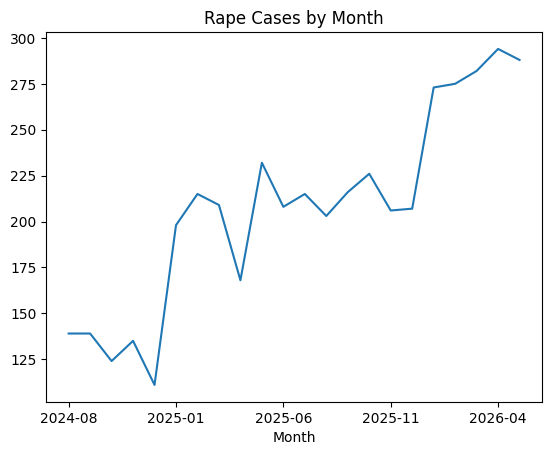

In [43]:
monthly = df.groupby("Month")["Rape"].sum()

monthly.plot()

plt.title("Rape Cases by Month")

plt.show()

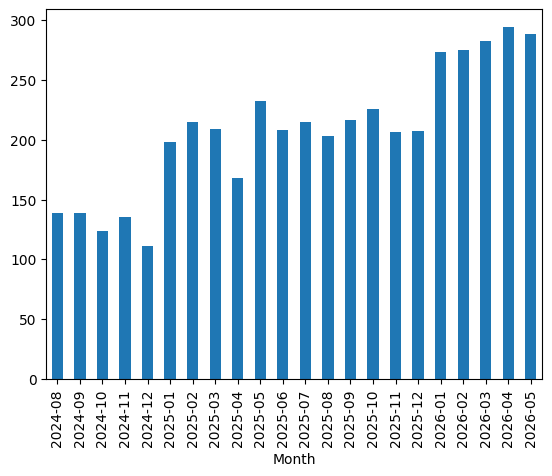

In [44]:
monthly_data = df.groupby("Month")["Rape"].sum()

monthly_data.plot(kind="bar")


plt.show()